In [28]:
import numpy as np
from time import perf_counter
from scipy.sparse.linalg import spsolve_triangular
from scipy.sparse import csc_matrix, tril, coo_matrix
from sksparse.cholmod import cholesky
from matplotlib import pyplot as plt

In [107]:
PATH_MATRIX = "data/A0031.txt"
PATH_COLUMN = "data/rhs0031.txt"
PATH_ORDERING = "data/ord0031.txt"

rows, cols = [], []
vals = []

with open(PATH_MATRIX, "r") as file:
    for line in file:
        str_rows, str_cols, str_vals = line.split(' ')
        rows.append(int(str_rows))
        cols.append(int(str_cols))
        vals.append(float(str_vals))

nestord = {}
nestord_anti = {}
with open(PATH_ORDERING, "r") as file:
    # Skip header
    next(file)
    for line in file:
        str_m, str_n = line.split(' ')
        nestord[int(str_m)] = int(str_n)
        nestord_anti[int(str_n)] = int(str_m)

rows_ord = [nestord[r] for r in rows]
cols_ord = [nestord[c] for c in cols]

l = max(rows) + 1
A_coo = coo_matrix((vals, (rows, cols)), shape=(l, l))
A_csc = csc_matrix(A_coo)

l = max(rows_ord) + 1
A_ord_coo = coo_matrix((vals, (rows_ord, cols_ord)), shape=(l, l))
A_ord_csc = csc_matrix(A_ord_coo)

b = np.loadtxt(PATH_COLUMN)
b_ord = np.stack((np.array([float(nestord[int(_)]) for _ in b[:, 0]]), b[:, 1]), axis=1)


if (A_csc.shape[0] != len(b)):
    print("Dimension mismatch...")


In [120]:
def my_cholesky(A_csc):
    factor = cholesky(A_csc, order="natural")
    return csc_matrix(factor[0])

t1 = perf_counter()

# Cholesky factorization needs positive definite, thus the minu
R = my_cholesky(-A_csc)
L = R.T.tocsc()

# Compensating the previous minus sign on b
y = spsolve_triangular(L, -b, lower=True)
x = spsolve_triangular(L.T, y, lower=False)

t2 = perf_counter()
tf = t2 - t1
print(f"{tf:.4f}")
print(L.nnz)


0.0159
29821


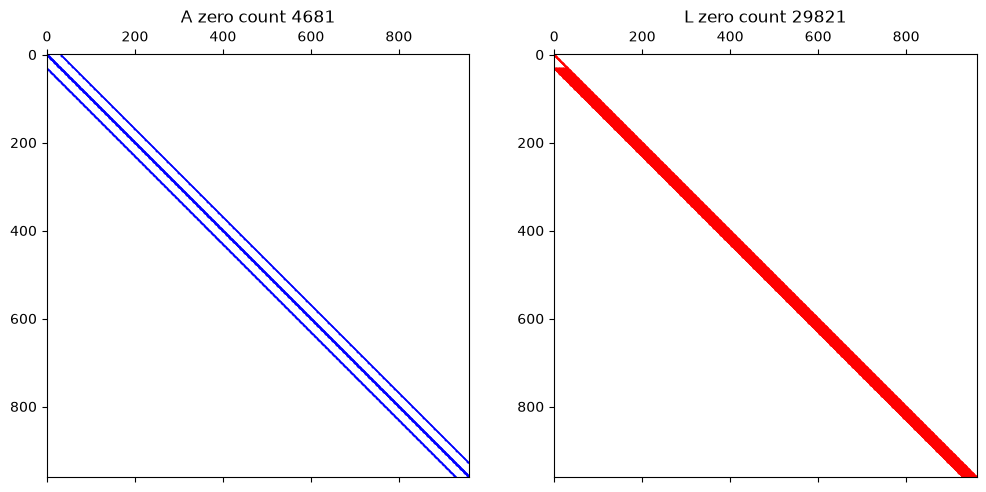

In [121]:
fig = plt.figure(figsize=(12,6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# Matrix A
ax1.spy(A_csc, markersize=0.3, color='blue')
ax1.set_title(f"A zero count {A_csc.nnz}")

# Matrix L
ax2.spy(L, markersize=0.3, color='red')
ax2.set_title(f"L zero count {L.nnz}")

plt.show()


In [129]:
N = 1023
PATH = "data/coords1023.txt"

coords = {}
with open(PATH, "r") as file:
    # Skip header
    next(file)
    for linea in file:
        s = linea.split()
        coords[int(s[0])] = (int(s[1]), int(s[2]), float(s[3]), float(s[4]))

U = np.zeros((N+2, N+2))

print(len(x[:,1]))
for nodo_id, (i, j, _, _) in coords.items():
    U[i, j] = x[:, 1][nodo_id]

fig, ax = plt.subplots(figsize=(6, 5))

cp = ax.imshow(U.T, origin='lower', 
               extent=[0, 1, 0, 1], 
               #extent=[x_min,x_max,y_min,y_max],
               cmap='turbo',          
               interpolation='none',     
               aspect='auto')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Temperatura u(x,y) — N={N_plot}")
plt.colorbar(cp, ax=ax, label="u(x,y)")

plt.show()

# Colorplot sorgente di calore
xx = np.linspace(0,1,1024)
yy = np.linspace(0,1,1024)
X,Y = np.meshgrid(xx,yy)

F = np.exp(-10*(X**2 + Y**2)) + X + Y

plt.figure(figsize=(6,5))
plt.imshow(F,
           origin="lower",
           extent=[0,1,0,1],
           cmap="turbo")
plt.colorbar(label="f(x,y)")
plt.title("Sorgente di calore")

plt.show()

961


IndexError: index 961 is out of bounds for axis 0 with size 961